In [1]:
import pandas as pd

# Step 1: Load the dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

# Preview the data
print(df.head())
df.dtypes
df.info()

df['Month'] = pd.to_datetime(df['Month'])

df.set_index('Month', inplace=True)
print(df.index)
print(df.head())

     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB
DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)
            Passengers
Month                 
1949-01-01         112
1949-02-01    

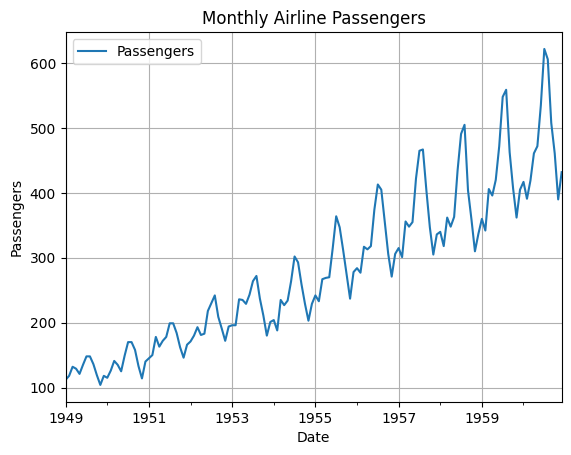

In [2]:
import matplotlib.pyplot as plt

df.plot(title="Monthly Airline Passengers")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.grid(True)
plt.show()

In [3]:
print(df.head())
# Create a full monthly date range from the start to the end of the dataset
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='MS')

df = df.reindex(full_range)
df.index.name = 'Month'

            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


In [4]:
missing_count = df['Passengers'].isna().sum()
print(f"Number of missing timestamps: {missing_count}")
print(df[df['Passengers'].isna()].head())

Number of missing timestamps: 0
Empty DataFrame
Columns: [Passengers]
Index: []


In [5]:

df['Passengers'].fillna(method='ffill', inplace=True)#Forward Fill
df['Passengers'].fillna(method='bfill', inplace=True)#Backward Fill
df['Passengers'].interpolate(method='linear', inplace=True)#interpolate Fill

C:\Users\Hait\AppData\Local\Temp\ipykernel_16412\750422886.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Passengers'].fillna(method='ffill', inplace=True)#Forward Fill
C:\Users\Hait\AppData\Local\Temp\ipykernel_16412\750422886.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Passengers'].fillna(method='ffill', inplace=True)#Forward Fill
C:\Users\Hait\AppData\Local\Temp\ipykernel_16412\750422886.py:2: FutureWarning: A value

In [6]:
df['Year'] = df.index.year
df['Month'] = df.index.month
df['Quarter'] = df.index.quarter
df['DayOfWeek'] = df.index.dayofweek  # Monday=0, Sunday=6
df['Month_Name'] = df.index.strftime('%b')  # e.g., Jan, Feb
print(df.head(12))

            Passengers  Year  Month  Quarter  DayOfWeek Month_Name
Month                                                             
1949-01-01         112  1949      1        1          5        Jan
1949-02-01         118  1949      2        1          1        Feb
1949-03-01         132  1949      3        1          1        Mar
1949-04-01         129  1949      4        2          4        Apr
1949-05-01         121  1949      5        2          6        May
1949-06-01         135  1949      6        2          2        Jun
1949-07-01         148  1949      7        3          4        Jul
1949-08-01         148  1949      8        3          0        Aug
1949-09-01         136  1949      9        3          3        Sep
1949-10-01         119  1949     10        4          5        Oct
1949-11-01         104  1949     11        4          1        Nov
1949-12-01         118  1949     12        4          3        Dec


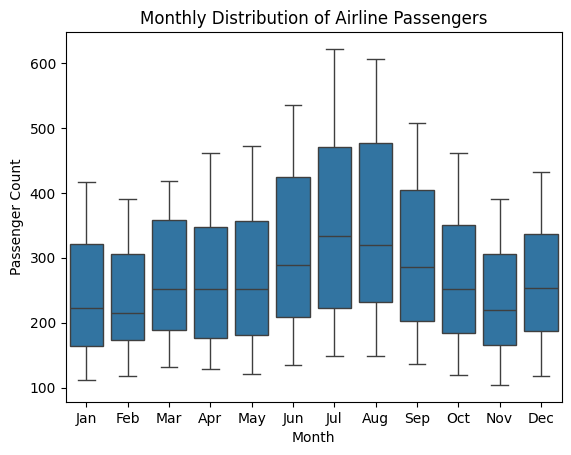

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Month_Name', y='Passengers', data=df.drop('Month', axis = 1).sort_values(by='Month'))
plt.title("Monthly Distribution of Airline Passengers")
plt.xlabel("Month")
plt.ylabel("Passenger Count")
plt.show()

**> This helps **visually detect seasonality** — do some months consistently have more traffic?

In [8]:
df['lag_1'] = df['Passengers'].shift(1)   # One period (month) back
df['lag_3'] = df['Passengers'].shift(3)   # Three months ago
df['lag_12'] = df['Passengers'].shift(12) # Same month last year

print(df[['Passengers', 'lag_1', 'lag_3', 'lag_12']].head(15))

            Passengers  lag_1  lag_3  lag_12
Month                                       
1949-01-01         112    NaN    NaN     NaN
1949-02-01         118  112.0    NaN     NaN
1949-03-01         132  118.0    NaN     NaN
1949-04-01         129  132.0  112.0     NaN
1949-05-01         121  129.0  118.0     NaN
1949-06-01         135  121.0  132.0     NaN
1949-07-01         148  135.0  129.0     NaN
1949-08-01         148  148.0  121.0     NaN
1949-09-01         136  148.0  135.0     NaN
1949-10-01         119  136.0  148.0     NaN
1949-11-01         104  119.0  148.0     NaN
1949-12-01         118  104.0  136.0     NaN
1950-01-01         115  118.0  119.0   112.0
1950-02-01         126  115.0  104.0   118.0
1950-03-01         141  126.0  118.0   132.0


In [9]:
df.dropna(inplace=True)

In [10]:
correlations = df[['Passengers', 'lag_1', 'lag_3', 'lag_12']].corr()
print(correlations)

            Passengers     lag_1     lag_3    lag_12
Passengers    1.000000  0.954294  0.818664  0.990527
lag_1         0.954294  1.000000  0.882805  0.949238
lag_3         0.818664  0.882805  1.000000  0.821849
lag_12        0.990527  0.949238  0.821849  1.000000


In [11]:
for lag in range(1, 13):
    df[f'lag_{lag}'] = df['Passengers'].shift(lag)

df.dropna(inplace=True)

In [12]:
df['rolling_mean_3'] = df['Passengers'].rolling(window=3).mean()
df['rolling_mean_6'] = df['Passengers'].rolling(window=6).mean()
df['rolling_mean_12'] = df['Passengers'].rolling(window=12).mean()

In [13]:
print(df[['Passengers', 'rolling_mean_3', 'rolling_mean_6', 'rolling_mean_12']].head(15))

            Passengers  rolling_mean_3  rolling_mean_6  rolling_mean_12
Month                                                                  
1951-01-01         145             NaN             NaN              NaN
1951-02-01         150             NaN             NaN              NaN
1951-03-01         178      157.666667             NaN              NaN
1951-04-01         163      163.666667             NaN              NaN
1951-05-01         172      171.000000             NaN              NaN
1951-06-01         178      171.000000      164.333333              NaN
1951-07-01         199      183.000000      173.333333              NaN
1951-08-01         199      192.000000      181.500000              NaN
1951-09-01         184      194.000000      182.500000              NaN
1951-10-01         162      181.666667      182.333333              NaN
1951-11-01         146      164.000000      178.000000              NaN
1951-12-01         166      158.000000      176.000000       170

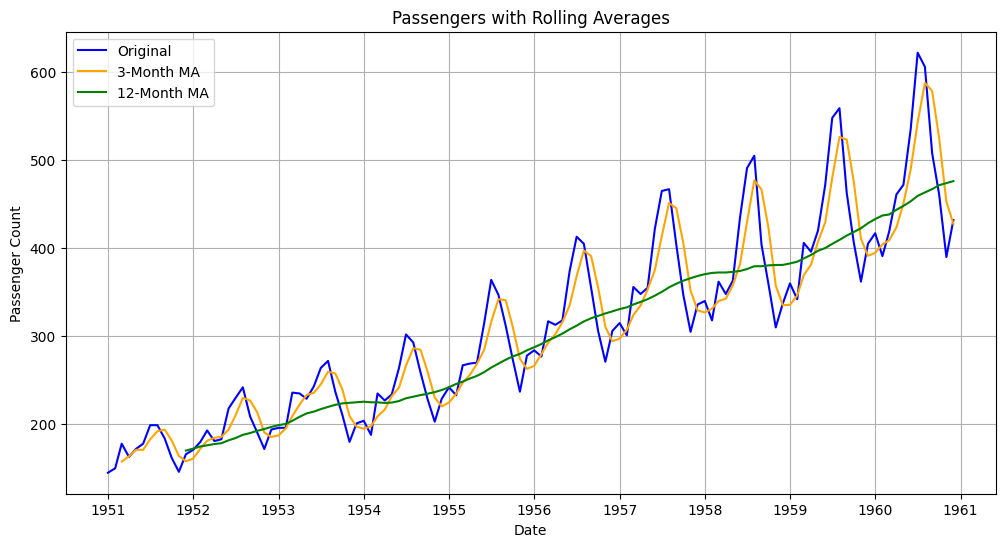

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['Passengers'], label='Original', color='blue')
plt.plot(df['rolling_mean_3'], label='3-Month MA', color='orange')
plt.plot(df['rolling_mean_12'], label='12-Month MA', color='green')
plt.title("Passengers with Rolling Averages")
plt.xlabel("Date")
plt.ylabel("Passenger Count")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
df.dropna(inplace=True)

In [16]:
print(f"Total records: {len(df)}")

Total records: 109


In [17]:
# Split index
train_size = len(df) - 12

# Chronologically split
train = df.iloc[:train_size]
test = df.iloc[train_size:]

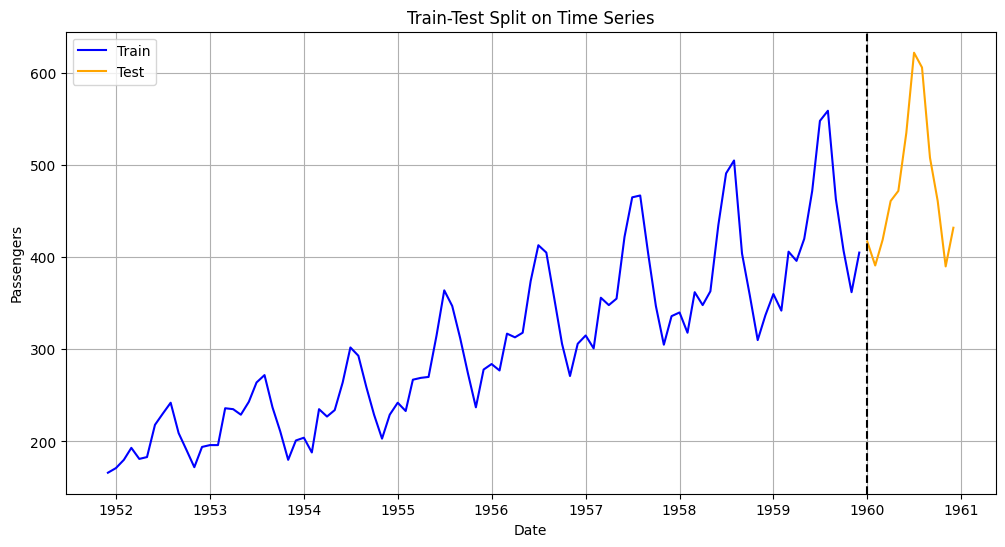

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(train.index, train['Passengers'], label='Train', color='blue')
plt.plot(test.index, test['Passengers'], label='Test', color='orange')
plt.axvline(test.index[0], color='black', linestyle='--')
plt.title("Train-Test Split on Time Series")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.grid(True)
plt.show()